In [1]:
# Xing et al., data - Updated classifier predictions to include additional ML_tranition and unclassified categories

In [2]:
import scanpy as sc
import anndata
import pandas as pd
from matplotlib import rcParams
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
adata = sc.read_h5ad("/Volumes/jennifer.a.foltz/Active/Veda/pan_cancer/Fan_brain_met/Xing_rds/batch_none/Fan_nk_eMLclassified_adata_batch_none.h5ad")

In [4]:
adata

AnnData object with n_obs × n_vars = 10353 × 4000
    obs: 'Disease', 'Study', 'SampleID', 'CancerType', 'CancerSubtype', 'EGFRtype', 'Treatment', 'Celltype', 'Subtype', 'batch', 'celltype.l2', 'dataset_name', '_scvi_labels', '_scvi_batch', 'CD56brightBBCprob', 'CD56dimBBCprob', 'eML1BBCprob', 'eML2BBCprob', 'predictionsBBC'
    uns: '_scvi_manager_uuid', '_scvi_uuid'
    obsm: 'X_totalvi_scarches', 'protein_expression'
    layers: 'counts'

In [54]:
adata.obs["batch"].unique()

['SampleID']
Categories (1, object): ['SampleID']

In [55]:
adata.obs

,Disease,Study,SampleID,CancerType,CancerSubtype,EGFRtype,Treatment,Celltype,Subtype,batch,celltype.l2,dataset_name,_scvi_labels,_scvi_batch,CD56brightBBCprob,CD56dimBBCprob,eML1BBCprob,eML2BBCprob,predictionsBBC,classification
Xing_BrM02_LC_AATGGAACAACGGCCT,BrM,Xing,BrM02,LC,Other,Other,Naive,T/NK cell,L20 : NK-FCGR3A,SampleID,Unknown,Query,0,3,0.005730,0.565306,0.372211,0.056753,CD56dim,CD56dim
Xing_BrM02_LC_AGTGTTGGTGAATGTA,BrM,Xing,BrM02,LC,Other,Other,Naive,T/NK cell,L20 : NK-FCGR3A,SampleID,Unknown,Query,0,3,0.000500,0.963111,0.032505,0.003885,CD56dim,CD56dim
Xing_BrM02_LC_CCACAAAAGACCGTTT,BrM,Xing,BrM02,LC,Other,Other,Naive,T/NK cell,L20 : NK-FCGR3A,SampleID,Unknown,Query,0,3,0.000239,0.862482,0.113108,0.024171,CD56dim,CD56dim
Xing_BrM02_LC_CGAAGGATCACCACAA,BrM,Xing,BrM02,LC,Other,Other,Naive,T/NK cell,L22 : NK-IFN,SampleID,Unknown,Query,0,3,0.000392,0.840216,0.052103,0.107289,CD56dim,CD56dim
Xing_BrM02_LC_CTAGACAAGTAAGCAT,BrM,Xing,BrM02,LC,Other,Other,Naive,T/NK cell,L20 : NK-FCGR3A,SampleID,Unknown,Query,0,3,0.000249,0.934569,0.045763,0.019419,CD56dim,CD56dim
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Xing_BrM99_HCC_TTTAGTCGTGCCTTCT,BrM,Xing,BrM99,HCC,Other,Other,Naive,T/NK cell,L20 : NK-FCGR3A,SampleID,Unknown,Query,0,3,0.000207,0.969836,0.004853,0.025104,CD56dim,CD56dim
Xing_BrM99_HCC_TTTATGCTCCACTGGG,BrM,Xing,BrM99,HCC,Other,Other,Naive,T/NK cell,L19 : NK-NCAM1,SampleID,Unknown,Query,0,3,0.070726,0.238062,0.549249,0.141963,ML1,ML1
Xing_BrM99_HCC_TTTGATCGTGCGACAA,BrM,Xing,BrM99,HCC,Other,Other,Naive,T/NK cell,L19 : NK-NCAM1,SampleID,Unknown,Query,0,3,0.000998,0.663616,0.077892,0.257494,CD56dim,CD56dim
Xing_BrM99_HCC_TTTGGAGTCAACCTTT,BrM,Xing,BrM99,HCC,Other,Other,Naive,T/NK cell,L20 : NK-FCGR3A,SampleID,Unknown,Query,0,3,0.004836,0.918610,0.024485,0.052069,CD56dim,CD56dim


In [56]:
adata.obs["predictionsBBC"].value_counts()

predictionsBBC
CD56dim       6432
ML1           2214
CD56bright     965
ML2            742
Name: count, dtype: int64

In [57]:
# Adding ML transition and unclassified 
#argmax error
# Define the column names for probabilities and their corresponding labels
probability_columns = ['CD56brightBBCprob', 'CD56dimBBCprob', 'eML1BBCprob', 'eML2BBCprob']
labels = ['CD56bright', 'CD56dim', 'ML1', 'ML2']

# Ensure the probability columns are numeric
for col in probability_columns:
    adata.obs[col] = pd.to_numeric(adata.obs[col], errors='coerce')  # Convert to numeric, set errors as NaN

# Function to classify rows based on conditions
def classify_row(row):
    # Check if all probabilities are less than 0.5
    if all(row[col] < 0.5 for col in probability_columns):
        # If combined probability of 'eML1BBCprob' and 'eML2BBCprob' is greater than 0.5, classify as ML_transition
        if row['eML1BBCprob'] + row['eML2BBCprob'] > 0.5:
            return 'ML_transition'
        else:
            return 'unclassified'
    else:
        # Find the column with the maximum probability
        max_index = row[probability_columns].astype(float).idxmax()  # Ensure values are treated as numeric
        return labels[probability_columns.index(max_index)]  # Return the corresponding label

# Apply the classification function to each row in `adata.obs`
adata.obs['classification'] = adata.obs.apply(classify_row, axis=1)

# View the first few rows to verify the classification
print(adata.obs[['CD56brightBBCprob', 'CD56dimBBCprob', 'eML1BBCprob', 'eML2BBCprob', 'classification']].head())

                                CD56brightBBCprob  CD56dimBBCprob  \
Xing_BrM02_LC_AATGGAACAACGGCCT           0.005730        0.565306   
Xing_BrM02_LC_AGTGTTGGTGAATGTA           0.000500        0.963111   
Xing_BrM02_LC_CCACAAAAGACCGTTT           0.000239        0.862482   
Xing_BrM02_LC_CGAAGGATCACCACAA           0.000392        0.840216   
Xing_BrM02_LC_CTAGACAAGTAAGCAT           0.000249        0.934569   

                                eML1BBCprob  eML2BBCprob classification  
Xing_BrM02_LC_AATGGAACAACGGCCT     0.372211     0.056753        CD56dim  
Xing_BrM02_LC_AGTGTTGGTGAATGTA     0.032505     0.003885        CD56dim  
Xing_BrM02_LC_CCACAAAAGACCGTTT     0.113108     0.024171        CD56dim  
Xing_BrM02_LC_CGAAGGATCACCACAA     0.052103     0.107289        CD56dim  
Xing_BrM02_LC_CTAGACAAGTAAGCAT     0.045763     0.019419        CD56dim  


In [58]:
adata.obs["classification"].value_counts()

classification
CD56dim          6124
ML1              1761
ML_transition     816
CD56bright        785
ML2               508
unclassified      359
Name: count, dtype: int64

In [61]:
adata.obs

,Disease,Study,SampleID,CancerType,CancerSubtype,EGFRtype,Treatment,Celltype,Subtype,batch,celltype.l2,dataset_name,_scvi_labels,_scvi_batch,CD56brightBBCprob,CD56dimBBCprob,eML1BBCprob,eML2BBCprob,predictionsBBC,classification
Xing_BrM02_LC_AATGGAACAACGGCCT,BrM,Xing,BrM02,LC,Other,Other,Naive,T/NK cell,L20 : NK-FCGR3A,SampleID,Unknown,Query,0,3,0.005730,0.565306,0.372211,0.056753,CD56dim,CD56dim
Xing_BrM02_LC_AGTGTTGGTGAATGTA,BrM,Xing,BrM02,LC,Other,Other,Naive,T/NK cell,L20 : NK-FCGR3A,SampleID,Unknown,Query,0,3,0.000500,0.963111,0.032505,0.003885,CD56dim,CD56dim
Xing_BrM02_LC_CCACAAAAGACCGTTT,BrM,Xing,BrM02,LC,Other,Other,Naive,T/NK cell,L20 : NK-FCGR3A,SampleID,Unknown,Query,0,3,0.000239,0.862482,0.113108,0.024171,CD56dim,CD56dim
Xing_BrM02_LC_CGAAGGATCACCACAA,BrM,Xing,BrM02,LC,Other,Other,Naive,T/NK cell,L22 : NK-IFN,SampleID,Unknown,Query,0,3,0.000392,0.840216,0.052103,0.107289,CD56dim,CD56dim
Xing_BrM02_LC_CTAGACAAGTAAGCAT,BrM,Xing,BrM02,LC,Other,Other,Naive,T/NK cell,L20 : NK-FCGR3A,SampleID,Unknown,Query,0,3,0.000249,0.934569,0.045763,0.019419,CD56dim,CD56dim
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Xing_BrM99_HCC_TTTAGTCGTGCCTTCT,BrM,Xing,BrM99,HCC,Other,Other,Naive,T/NK cell,L20 : NK-FCGR3A,SampleID,Unknown,Query,0,3,0.000207,0.969836,0.004853,0.025104,CD56dim,CD56dim
Xing_BrM99_HCC_TTTATGCTCCACTGGG,BrM,Xing,BrM99,HCC,Other,Other,Naive,T/NK cell,L19 : NK-NCAM1,SampleID,Unknown,Query,0,3,0.070726,0.238062,0.549249,0.141963,ML1,ML1
Xing_BrM99_HCC_TTTGATCGTGCGACAA,BrM,Xing,BrM99,HCC,Other,Other,Naive,T/NK cell,L19 : NK-NCAM1,SampleID,Unknown,Query,0,3,0.000998,0.663616,0.077892,0.257494,CD56dim,CD56dim
Xing_BrM99_HCC_TTTGGAGTCAACCTTT,BrM,Xing,BrM99,HCC,Other,Other,Naive,T/NK cell,L20 : NK-FCGR3A,SampleID,Unknown,Query,0,3,0.004836,0.918610,0.024485,0.052069,CD56dim,CD56dim


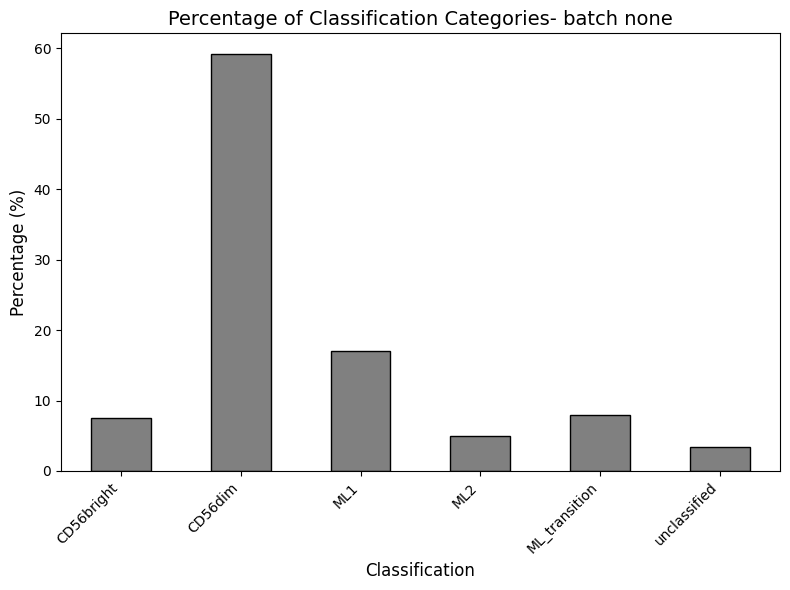

In [63]:
# Define the desired order for classification categories
desired_order = ['CD56bright', 'CD56dim', 'ML1', 'ML2', 'ML_transition', 'unclassified']

# Calculate the percentage of each classification category
classification_counts = adata.obs['classification'].value_counts(normalize=True) * 100

# Reorder classification_counts based on the desired order
classification_counts = classification_counts[desired_order]

# Plot the percentages with the desired order
plt.figure(figsize=(8, 6))
classification_counts.plot(kind='bar', color='grey', edgecolor='black')
plt.title('Percentage of Classification Categories- batch none', fontsize=14)
plt.xlabel('Classification', fontsize=12)
plt.ylabel('Percentage (%)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [66]:
adata.obs.groupby("CancerType")["SampleID"].nunique()

/var/folders/kd/m1qdx0dj5yj9ccknd3w46p9m0000gr/T/ipykernel_66228/1979318259.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  adata.obs.groupby("CancerType")["SampleID"].nunique()


CancerType
BC         16
CRC         7
ESCC        3
HCC         3
LC         41
MEL         1
Other       4
Sarcoma     4
Name: SampleID, dtype: int64

In [67]:
adata.obs.groupby("CancerType")["SampleID"].nunique()

/var/folders/kd/m1qdx0dj5yj9ccknd3w46p9m0000gr/T/ipykernel_66228/1979318259.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  adata.obs.groupby("CancerType")["SampleID"].nunique()


CancerType
BC         16
CRC         7
ESCC        3
HCC         3
LC         41
MEL         1
Other       4
Sarcoma     4
Name: SampleID, dtype: int64

In [68]:
adata.obs.groupby("CancerSubtype")["SampleID"].nunique()

/var/folders/kd/m1qdx0dj5yj9ccknd3w46p9m0000gr/T/ipykernel_66228/2382057788.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  adata.obs.groupby("CancerSubtype")["SampleID"].nunique()


CancerSubtype
BC-HR+HER2+     4
BC-HR+HER2-     2
BC-HR-HER2+     6
BC-TNBC         4
LC-SCLC         6
NSCLC-LCLC      3
NSCLC-LUAD     28
NSCLC-LUSC      3
Other          23
Name: SampleID, dtype: int64